# HF TDOA Analysis - Figure 8

This notebook creates Figure 8: Same Path Different Frequencies.

Shows layer height measurements from AB5YO on both 7.2 MHz (5.3 MHz) and 5.3 MHz (7.3 MHz) bands over the same path.

In [1]:
import datetime
import matplotlib.pyplot as plt
import hf_tdoa as tdoa

%matplotlib inline

# Setup plotting style
tdoa.setup_plotting_style()

## Create Figure 8: AB5YO 7.2 MHz and 5.3 MHz Subplots

Figure 8 shows layer height measurements from AB5YO on both 7.2 MHz (5.3 MHz, top panel) and 5.3 MHz (7.3 MHz, bottom panel) bands, demonstrating how different frequencies over the same path produce different height profiles.

Figure saved to: fig_08.jpg


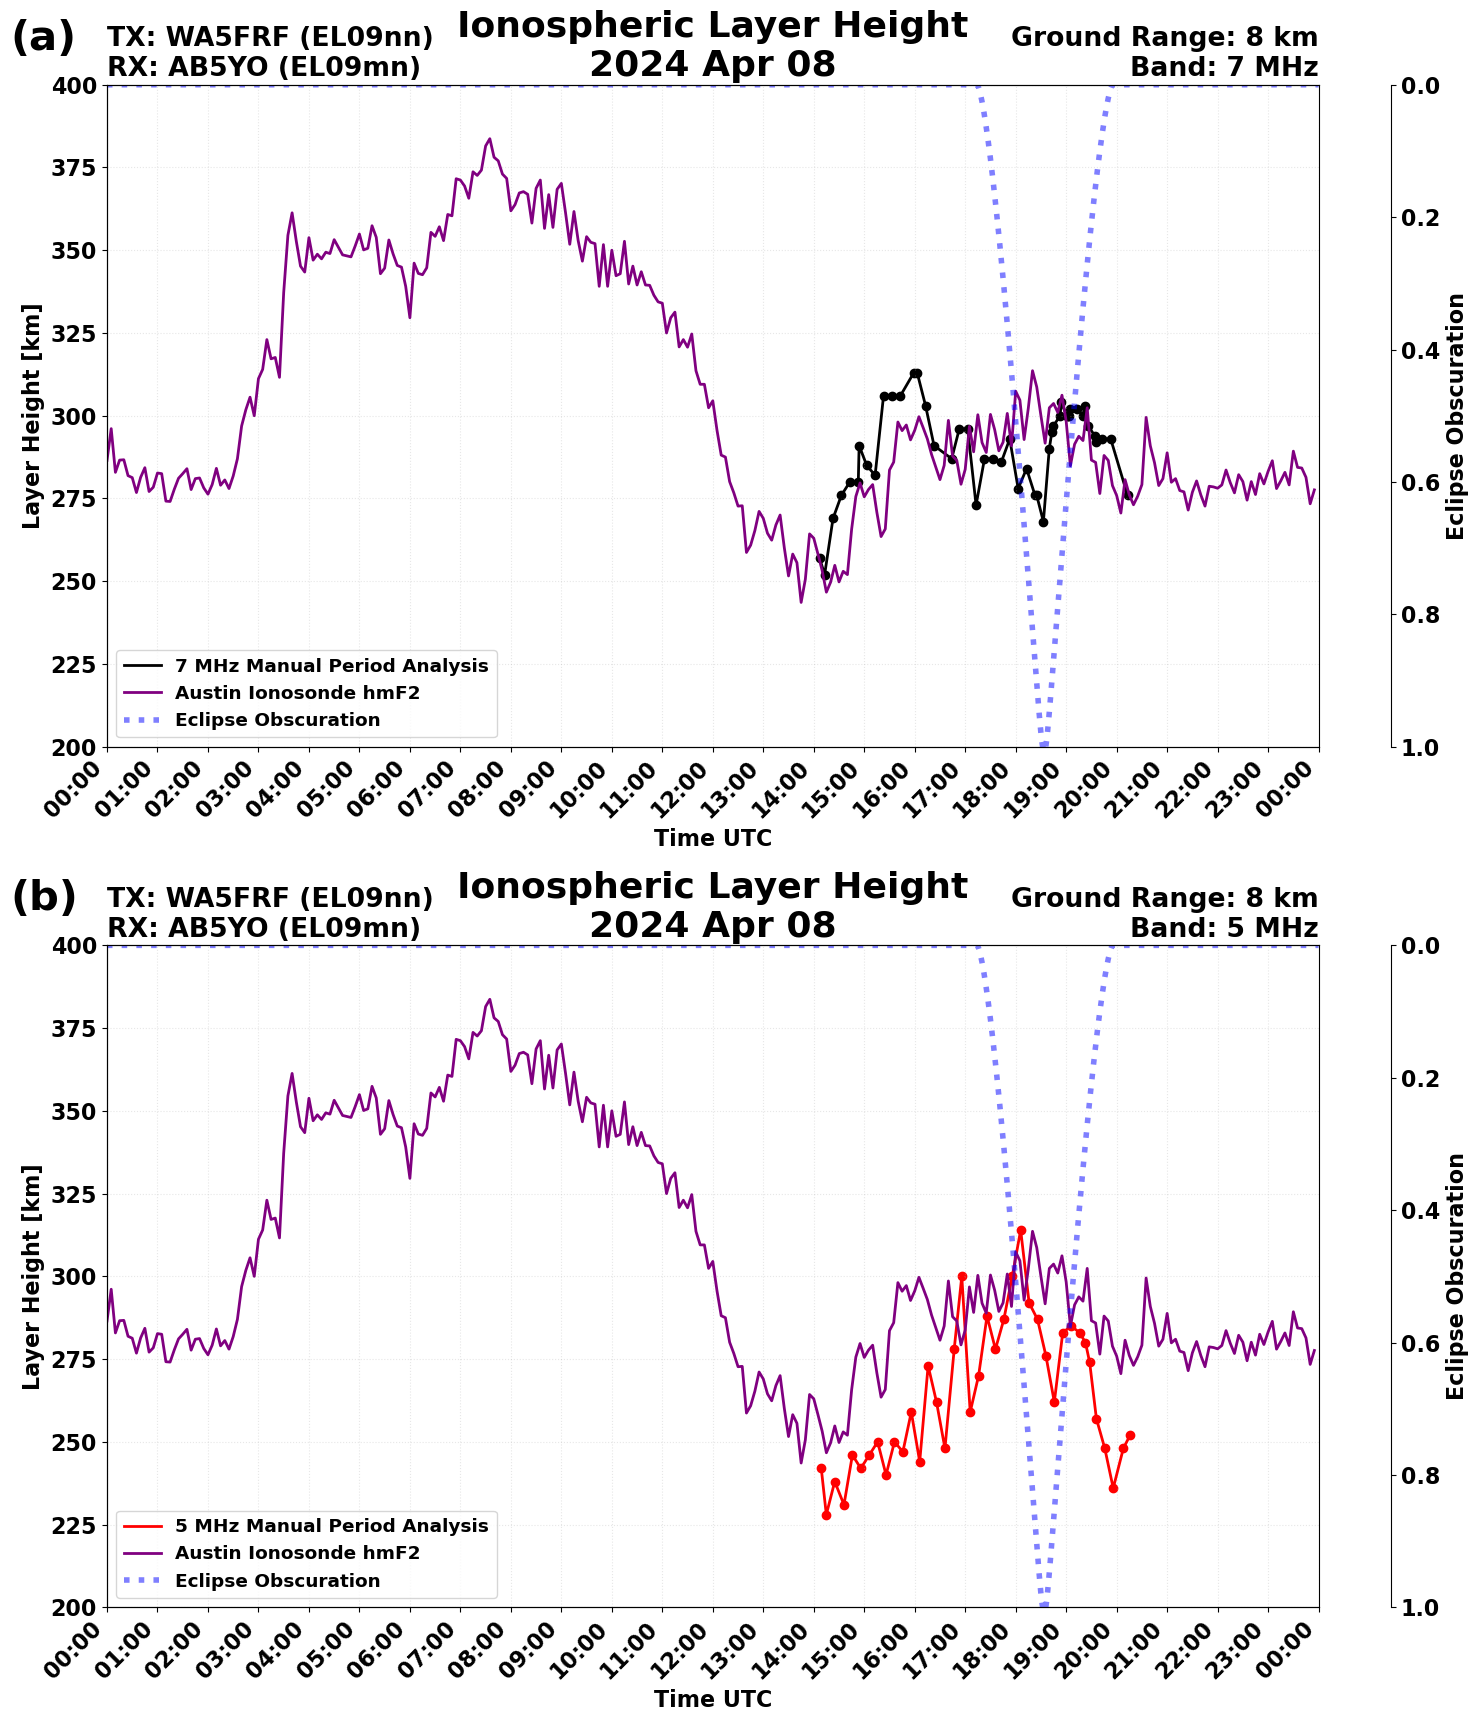

In [2]:
# Create PathInfo objects for titles
path_info_40m = tdoa.PathInfo('TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m')
path_info_60m = tdoa.PathInfo('TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-60m')

# Get solar coordinates for eclipse overlay
solar_lat, solar_lon = path_info_40m.get_midpoint()

# Date for titles
date = datetime.datetime(2024, 4, 8)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 17.5))

# Set time limits for consistent x-axis across subplots - full day
xlim = (datetime.datetime(2024, 4, 8), datetime.datetime(2024, 4, 9))
ylim = (200, 400)

# Panel (a): 7.2 MHz (7.2 MHz) data
tdoa.overlay_tdoa_csv(
    ax1,
    csv_path_period='../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m_manual_period_analysis.csv',
    label_period=f'{path_info_40m.band_str} Manual Period Analysis',
    color_period='black',
    linestyle_period='solid'
)

tdoa.overlay_ionosonde(
    ax1,
    csv_path='../data/CSVs/2024-04-08_AU930_AustinTX_Ionosonde_ManualScaled.csv',
    overlay_hmF2=True,
    overlay_hmE=False,
    label='Austin Ionosonde',
    hmF2_color='purple'
)

# Add solar elevation and eclipse overlay for panel (a)
from hf_tdoa import solarContext
solar_ts_1 = solarContext.solarTimeseries(
    sTime=xlim[0],
    eTime=xlim[1],
    lat=solar_lat,
    lon=solar_lon
)
# Collect lines for legend
eclipse_line_1 = solar_ts_1.overlayEclipse(ax1)

# Format x-axis with datetime formatting
from matplotlib import dates as mdates
myFmt = mdates.DateFormatter('%H:%M')
ax1.xaxis.set_major_formatter(myFmt)
ax1.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))

ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_ylabel('Layer Height [km]')
ax1.set_xlabel('Time UTC')
ax1.grid(True, alpha=0.3)

# Create legend with all elements including eclipse
handles, labels = ax1.get_legend_handles_labels()
if eclipse_line_1 is not None:
    handles.append(eclipse_line_1)
    labels.append(eclipse_line_1.get_label())
ax1.legend(handles=handles, labels=labels, loc='lower left', fontsize='small')

# Add title using the library's formatting
tdoa.title_from_pfx(ax1, path_info_40m, date=date, center_title='Ionospheric Layer Height')

# Add subplot label
ax1.text(-0.08, 1.100, '(a)', transform=ax1.transAxes,
         fontsize=30, fontweight='bold', va='top', ha='left')

# Panel (b): 5.3 MHz (5.3 MHz) data
tdoa.overlay_tdoa_csv(
    ax2,
    csv_path_period='../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-60m_manual_period_analysis.csv',
    label_period=f'{path_info_60m.band_str} Manual Period Analysis',
    color_period='red',
    linestyle_period='solid'
)

tdoa.overlay_ionosonde(
    ax2,
    csv_path='../data/CSVs/2024-04-08_AU930_AustinTX_Ionosonde_ManualScaled.csv',
    overlay_hmF2=True,
    overlay_hmE=False,
    label='Austin Ionosonde',
    hmF2_color='purple'
)

# Add solar elevation and eclipse overlay for panel (b)
solar_ts_2 = solarContext.solarTimeseries(
    sTime=xlim[0],
    eTime=xlim[1],
    lat=solar_lat,
    lon=solar_lon
)
# Collect lines for legend
eclipse_line_2 = solar_ts_2.overlayEclipse(ax2)

# Format x-axis with datetime formatting
ax2.xaxis.set_major_formatter(myFmt)
ax2.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))

ax2.set_xlim(xlim)
ax2.set_ylim(ylim)
ax2.set_ylabel('Layer Height [km]')
ax2.set_xlabel('Time UTC')
ax2.grid(True, alpha=0.3)

# Create legend with all elements including eclipse
handles, labels = ax2.get_legend_handles_labels()
if eclipse_line_2 is not None:
    handles.append(eclipse_line_2)
    labels.append(eclipse_line_2.get_label())
ax2.legend(handles=handles, labels=labels, loc='lower left', fontsize='small')

# Add title using the library's formatting
tdoa.title_from_pfx(ax2, path_info_60m, date=date, center_title='Ionospheric Layer Height')

# Add subplot label
ax2.text(-0.08, 1.100, '(b)', transform=ax2.transAxes,
         fontsize=30, fontweight='bold', va='top', ha='left')

# Rotate x-axis labels
for ax in [ax1, ax2]:
    for tick_label in ax.get_xticklabels():
        tick_label.set_rotation(45)
        tick_label.set_horizontalalignment('right')

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)

# Save figure
plt.savefig('fig_08.jpg', dpi=300, bbox_inches='tight', format='jpeg', pil_kwargs={'quality': 95})
print("Figure saved to: fig_08.jpg")

plt.show()